# Convolutional Neural Network (CNN)

## Use MNIST Fashion dataset and create a classifier to classify fashion clothing into categories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
import keras

I0000 00:00:1778138046.093246    9265 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778138046.100867    9265 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778138046.802791    9265 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778138049.620554    9265 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
#read data
train_df= pd.read_csv('fashion-mnist_train.csv')
# test_data=pd.read_csv('fashion-mnist_test.csv')

In [3]:
import pandas as pd

# Load original dataset
df = pd.read_csv("fashion-mnist_train.csv")

# Take 10,000 random rows as test data
test_df = df.sample(n=10000, random_state=42)

# Save to new CSV
test_df.to_csv("fashion-mnist_test_file.csv", index=False)

print("Test file created successfully!")

Test file created successfully!


In [4]:
train_df.shape

(60000, 785)

In [5]:
test_df.shape

(10000, 785)

In [6]:
test_df = pd.read_csv("fashion-mnist_test_file.csv")
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,0,0,0,0,0,0,0,0,0,...,187,190,196,201,209,221,218,211,102,0
2,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_df = pd.read_csv("fashion-mnist_train.csv")
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Extract feature values (all columns except 'label') from training dataset
x_train = train_df.drop(columns=["label"]).values  

# Extract target labels from training dataset
y_train = train_df["label"].values  

# Extract feature values (all columns except 'label') from testing dataset
x_test = test_df.drop(columns=["label"]).values  

# Extract target labels from testing dataset
y_test = test_df["label"].values  

In [9]:
# Reshape training data into 28x28 images with 1 channel (grayscale)
# -1 automatically calculates the number of samples
x_train = x_train.reshape(-1, 28, 28, 1)

# Reshape testing data into 28x28 images with 1 channel (grayscale)
x_test = x_test.reshape(-1, 28, 28, 1)

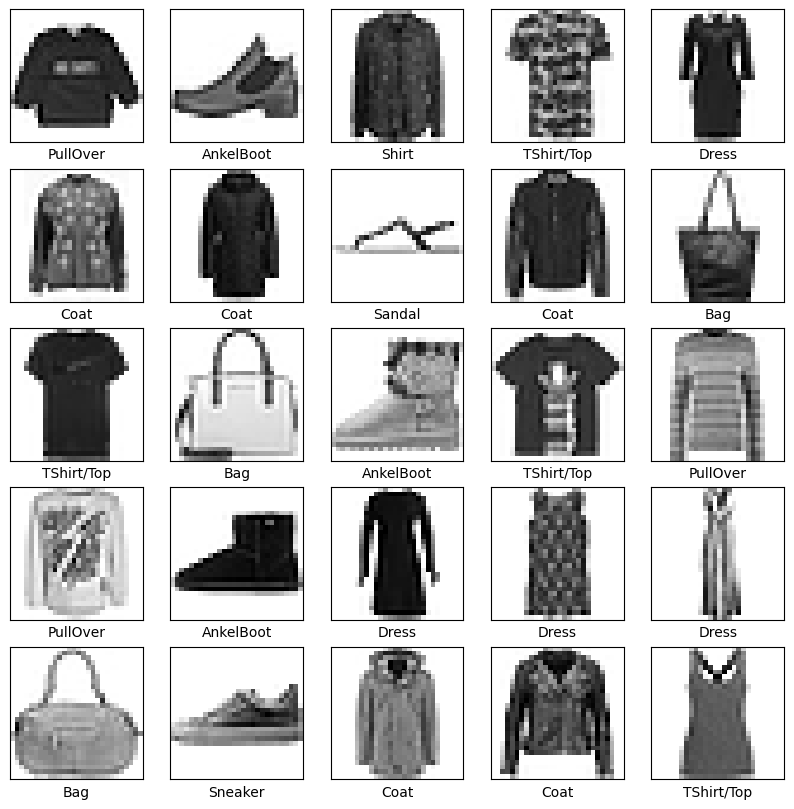

In [10]:
#Data visualization
names=['TShirt/Top','Trouser','PullOver','Dress','Coat','Sandal','Shirt','Sneaker','Bag','AnkelBoot']
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i],cmap=plt.cm.binary)
  plt.xticks([])
  plt.yticks([])
  plt.xlabel(names[y_train[i]])
  plt.grid(False)

plt.show()

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout


model = Sequential([

    # 1st Convolution Layer
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    # 1st Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # 2nd Convolution Layer
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    # 2nd Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

In [14]:
#Model compiling
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#Model training
model.fit(x=x_train, y=y_train, batch_size=32, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7586 - loss: 0.7820 - val_accuracy: 0.8428 - val_loss: 0.4207
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8393 - loss: 0.4477 - val_accuracy: 0.8690 - val_loss: 0.3549
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8540 - loss: 0.3979 - val_accuracy: 0.8752 - val_loss: 0.3378
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8627 - loss: 0.3708 - val_accuracy: 0.8771 - val_loss: 0.3321
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8701 - loss: 0.3515 - val_accuracy: 0.8845 - val_loss: 0.3116


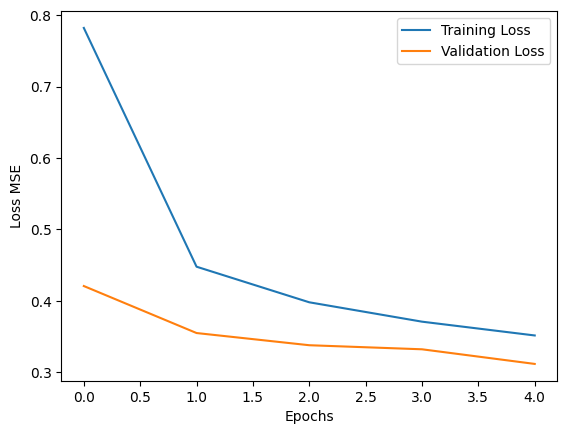

In [15]:
plt.plot(model.history.history["loss"], label="Training Loss")
plt.plot(model.history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss MSE")
plt.legend()
plt.show()

In [16]:
#Model evaluation
loss, accuracy = model.evaluate(x=x_test, y=y_test)
print("Loss : ", loss)
print("Accuracy : ", accuracy*100) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8974 - loss: 0.2735
Loss :  0.27347975969314575
Accuracy :  89.74000215530396


In [20]:
# Predictions
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(x_test), axis=1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1032
           1       0.99      0.98      0.99       974
           2       0.84      0.82      0.83      1001
           3       0.89      0.93      0.91      1037
           4       0.80      0.80      0.80       992
           5       0.98      0.98      0.98       946
           6       0.71      0.69      0.70      1047
           7       0.97      0.97      0.97       999
           8       0.99      0.98      0.98       952
           9       0.98      0.97      0.98      1020

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [17]:
#Testing the prediction vs Actual
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test[:10]

print("Predicted : ", predicted_classes)
print("True : ", true_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted :  [7 8 8 5 9 1 2 3 6 2]
True :  [7 8 8 5 9 1 2 6 6 2]
